## Topic: Deep Learning Models for Chest Disease Classification – Normal, Pneumonia, and Tuberculosis Detection

**Business Problem:** Early identification of chest diseases such as Pneumonia and Tuberculosis is essential for timely treatment and reducing mortality. However, manual chest X-ray interpretation is slow, subjective, and requires expert radiologists. The business challenge is to build a Convolutional Neural Network (CNN) model that can automatically classify chest X-ray images into Normal, Pneumonia, or Tuberculosis. This assists hospitals and screening centers in faster triage, reducing diagnostic errors, and improving workflow efficiency.

**Dataset:** https://www.kaggle.com/datasets/muhammadrehan00/chest-xray-dataset

**Models:**
1. CNN
2. DenseNet121

**Dataset Description:**
- The dataset contains X-ray images of chest conditions classified into three categories(Normal, Pneumonia, Tuberculosis)
- The dataset is already divided into train, validation & test sets.

### Import Libraries

- Imports pandas and numpy for data handling and numerical operations
- Imports matplotlib for plotting and visualization
- Imports TensorFlow and Keras for building deep learning models
- Uses image_dataset_from_directory to load image data from folders
- Imports CNN layers like Conv2D, MaxPooling, Dense, Dropout, BatchNormalization
- Uses GlobalAveragePooling2D for efficient feature reduction
- Imports EarlyStopping to prevent overfitting during training
- Uses pickle to save and load models or related objects
- Imports DenseNet121, a pre-trained CNN architecture
- Suppresses warnings to keep output clean

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras.preprocessing import image_dataset_from_directory
from keras.models import Sequential, load_model, Model
from keras.layers import Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping

import pickle

import warnings
warnings.filterwarnings("ignore")

1. "archive/train" → Specifies the folder containing training images
- Why: Keras reads images directly from directory structure

2. labels="inferred" → Automatically assigns labels from subfolder names
- Why: Avoids manual labeling

3. label_mode="categorical" → Converts labels to one-hot encoded format
- Why: Required for multi-class classification (3 classes)

4. color_mode="grayscale" → Loads images in single channel
- Why: Reduces computation and model complexity

5. batch_size=32 → Loads 32 images per batch
- Why: Balances memory usage and training stability

6. image_size=(256,256) → Resizes all images to same dimensions
- Why: CNNs require uniform input size

7. shuffle=True → Randomizes image order
- Why: Prevents model bias and improves generalization

8. seed=42 → Fixes randomness
- Why: Ensures reproducible results

9. interpolation="bilinear" → Smooth resizing technique
- Why: Preserves image quality during resizing

**Result:** Dataset contains 20,450 training images across 3 classes

### Load Dataset

In [5]:
# Load train data
train_ds = image_dataset_from_directory(
    "archive/train",
    labels = "inferred",
    label_mode = "categorical",
    color_mode = "grayscale",
    batch_size=32,
    image_size=(256,256),
    shuffle = True,
    seed = 42,
    interpolation = "bilinear"
)

print(train_ds)

Found 20450 files belonging to 3 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>


- This code loads the validation dataset with the same preprocessing steps as training data to fairly evaluate the model during training.
- **Result:** Dataset contains 2,534 validation images across 3 classes

In [6]:
# Load validation data
val_ds = image_dataset_from_directory(
    "archive/val",
    labels = "inferred",
    label_mode = "categorical",
    color_mode = "grayscale",
    batch_size = 32,
    image_size = (256,256),
    shuffle = True,
    seed = 42,
    interpolation = "bilinear"
)

print(val_ds)

Found 2534 files belonging to 3 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>


- This code loads the test dataset with the same preprocessing as training data to perform final model evaluation fairly and consistently.
- **Result:** Dataset contains 2,569 testing images across 3 classes

In [7]:
# Load Test data
test_ds = image_dataset_from_directory(
    "archive/test",
    labels = "inferred",
    label_mode = "categorical",
    color_mode = "grayscale",
    batch_size = 32,
    image_size = (256,256),
    shuffle = True,
    seed = 42,
    interpolation = "bilinear"
)

print(test_ds)

Found 2569 files belonging to 3 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>


### EDA

- Gets the names of all classes from the training data
- Counts how many classes are present
- Prints class names for checking
- From here, it is observed that Total 3 classes are there('normal', 'pneumonia', 'tuberculosis').

In [8]:
# Total Classes
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['normal', 'pneumonia', 'tuberculosis']
Number of classes: 3


- The dataset is well split into training, validation, and test sets.
- Most images (20,450) are used for training to help the model learn patterns.
- Validation (2,534) is used to tune the model and prevent overfitting.
- Test data (2,569) is kept unseen for final performance evaluation.

In [9]:
# Size of the Train-Validation-Test set
print("Train images:", len(train_ds.file_paths))
print("Validation images:", len(val_ds.file_paths))
print("Test images:", len(test_ds.file_paths))

Train images: 20450
Validation images: 2534
Test images: 2569


- The dataset is slightly imbalanced across the three classes.
- Tuberculosis has the highest number of images (8,513).
- Normal cases are also well represented (7,263).
- Pneumonia has the least samples (4,674).

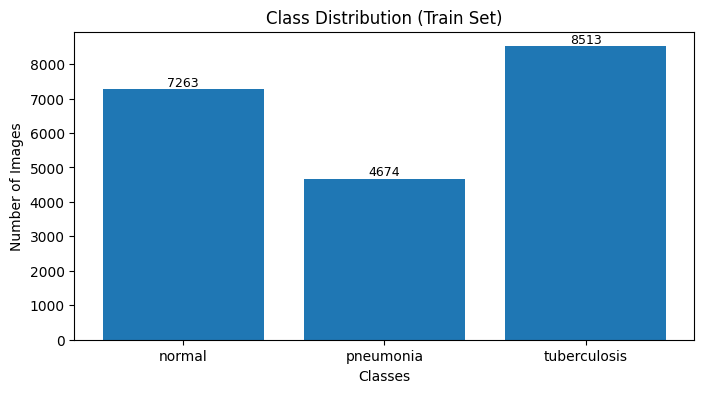

In [12]:
# Extract class index
image_label_indices = [
    class_names.index(file_path.split('/')[-2])
    for file_path in train_ds.file_paths
]

# Number of images per class
images_per_class = np.bincount(
    image_label_indices,
    minlength=num_classes
)

# Distribution of classes
plt.figure(figsize=(8,4))
bars = plt.bar(class_names, images_per_class)
plt.title("Class Distribution (Train Set)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()

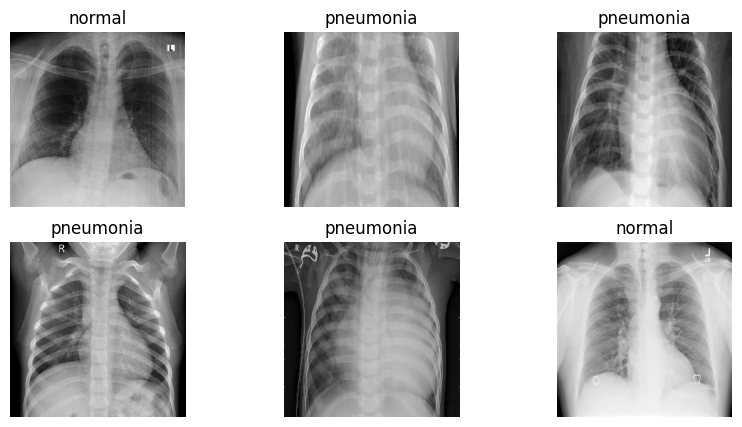

In [13]:
# Visualise sample images
plt.figure(figsize=(10,5))

for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")


- Pixel values range from 0 to 255, showing grayscale X-ray images.
- A large spike near 0 means many dark/background pixels (lungs + borders).
- Most pixels lie between 50 and 200, representing actual chest structures.
- Distribution is not uniform, so normalization is important before training CNN/DenseNet models.

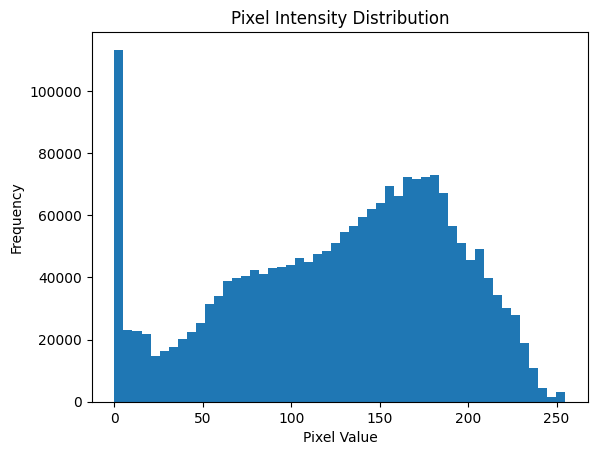

In [14]:
# Distribution of pixels Intensity
for images, _ in train_ds.take(1):
    pixels = images.numpy().flatten()

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

### Normalization:

This code normalizes all image datasets by scaling pixel values to improve training stability and model performance.

1. Rescaling(1./255) → Scales pixel values from 0–255 to 0–1
- Why: Improves numerical stability and faster model convergence

2. train_ds.map(...) → Applies normalization to training images
- Why: Ensures consistent input range during learning

3. val_ds.map(...) → Applies normalization to validation images
- Why: Validation data must match training preprocessing

4. test_ds.map(...) → Applies normalization to test images
- Why: Guarantees fair and accurate evaluation

5. lambda x, y: (normalization_layer(x), y)
- Why: Normalizes images (x) while keeping labels (y) unchanged

In [ ]:
# Define the normalization
normalization_layer = Rescaling(1./255)

# Apply normalization on train, validation & test data
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))


## CNN 1:

- This CNN model extracts image features using convolution layers and performs multi-class classification using a softmax output layer.

1. Sequential() → Builds the model layer by layer
- Why: Simple and suitable for basic CNN architectures

2. Conv2D(32, (3,3), activation="relu") → First convolution layer
- Why: Extracts low-level features like edges and textures

3. MaxPooling2D(2,2) → Reduces spatial dimensions
- Why: Lowers computation and helps prevent overfitting

4. BatchNormalization() → Normalizes activations
- Why: Improves training stability and convergence

5. Conv2D(64, (3,3), activation="relu") → Deeper convolution layer
- Why: Learns more complex image features

6. Flatten() → Converts feature maps into 1D vector
- Why: Prepares data for fully connected layers

7. Dense(64, activation="relu") → Fully connected layer
Why: Learns non-linear class representations

8. Dropout(0.5) → Randomly drops 50% neurons
- Why: Prevents overfitting

9. Dense(num_classes, activation="softmax") → Output layer
- Why: Produces class probabilities for multi-class classification

In [ ]:
# Define the CNN model 1
cnn_model_1 = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(256,256,1)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),
    Dense(64, activation = "relu"),
    Dropout(0.5),

    Dense(num_classes, activation = "softmax"),
])

# Summary of CNN model 1
cnn_model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 127, 127, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    15,745,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,764,483 (60.14 MB)

 Trainable params: 15,764,291 (60.14 MB)

 Non-trainable params: 192 (768.00 B)

### Early stopping:

Early stopping halts training when validation loss stops improving and restores the best model weights to avoid overfitting.

1. EarlyStopping() → Callback to stop training automatically
- Why: Prevents overfitting and unnecessary training

2. monitor="val_loss" → Tracks validation loss
- Why: Validation loss reflects model generalization

3. patience=5 → Waits for 5 epochs without improvement
- Why: Allows small fluctuations before stopping

4. verbose=1 → Displays stopping information
- Why: Provides training feedback

5. restore_best_weights=True → Restores best model weights
- Why: Ensures final model uses the best-performing parameters

In [ ]:
# Define Early Stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=1,
    restore_best_weights=True
)

This code compiles the CNN model with Adam optimizer, categorical cross-entropy loss, and accuracy metric for multi-class classification.

1. optimizer="adam" → Uses Adam optimization algorithm
- Why: Efficient, adaptive learning for faster convergence

2. loss="categorical_crossentropy" → Multi-class classification loss
- Why: Suitable for one-hot encoded labels

3. metrics="accuracy" → Tracks training and validation accuracy
- Why: Evaluates model performance during training

In [ ]:
# # Compile CNN model 1
# cnn_model_1.compile(
#     optimizer="adam",
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

This line trains the CNN on the training dataset while validating on the validation set and using early stopping to prevent overfitting.

1. cnn_model_1.fit() → Starts training the CNN model
- Why: Updates model weights using training data

2. train_ds → Training dataset
- Why: Provides input images and labels for learning

3. epochs=50 → Maximum number of training iterations
- Why: Allows sufficient time for model to learn patterns

4. validation_data=val_ds → Validation dataset
- Why: Monitors model performance on unseen data during training

5. callbacks=early_stopping → Applies early stopping
- Why: Stops training if validation loss stops improving, preventing overfitting

6. history_1 → Stores training metrics (accuracy, loss)
- Why: Useful for plotting and analyzing training progress

In [ ]:
# # Train the CNN model 1
# history_1 = cnn_model_1.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=[early_stopping])

- This code loads a pre-trained CNN model from file so it can be used directly for evaluation or predictions.

In [ ]:
# Load the CNN model 1
cnn_model_1 = load_model('cnn_model_1.keras')

- This line saves the trained CNN model so it can be reused for evaluation or predictions without retraining.

In [ ]:
# # Save the CNN model 1
# cnn_model_1.save("cnn_model_1.keras")

- This code loads the saved training history of CNN model 1 to visualize or analyze its performance.

In [ ]:
# Load the parameters of CNN 1
with open("history_1.pkl", "rb") as f:
  history_1 = pickle.load(f)

- This code saves the training history of CNN model 1 so it can be reloaded later for analysis or plotting.

In [ ]:
# # Save the parameters of CNN 1
# with open("history_1.pkl", "wb") as f:
#     pickle.dump(history_1, f)

- This code Calculates number of epochs from training history.
- Retrieves training and validation accuracy
- Retrieves training and validation loss
- Sets up a figure for plotting
- Plots training vs validation accuracy in first subplot
- Plots training vs validation loss in second subplot
- Adds labels, titles, and legends for clarity
- Displays the plots for visual analysis of model performance

In [ ]:
# Function to plot accuracy and loss
def visulize_training(hist):
    epochs = range(1, len(hist.history["loss"]) + 1)

    train_acc = hist.history.get('accuracy')
    val_acc = hist.history.get('val_accuracy')
    train_loss = hist.history.get('loss')
    val_loss = hist.history.get('val_loss')

    plt.figure(figsize=(12,6))

    # Accuracy Plot
    plt.subplot(1,2,1)
    plt.plot(epochs, train_acc, marker='o', linestyle='-', label = 'Train Accuracy')
    plt.plot(epochs, val_acc, marker='x', linestyle='--', label = "Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy over Epochs")
    plt.legend()

    # Loss Plot
    plt.subplot(1,2,2)
    plt.plot(epochs, train_loss, marker='o', linestyle='-', label = "Train Loss")
    plt.plot(epochs, val_loss, marker='x', linestyle='--', label = "Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Model Loss over Epochs")
    plt.legend()

    plt.show()


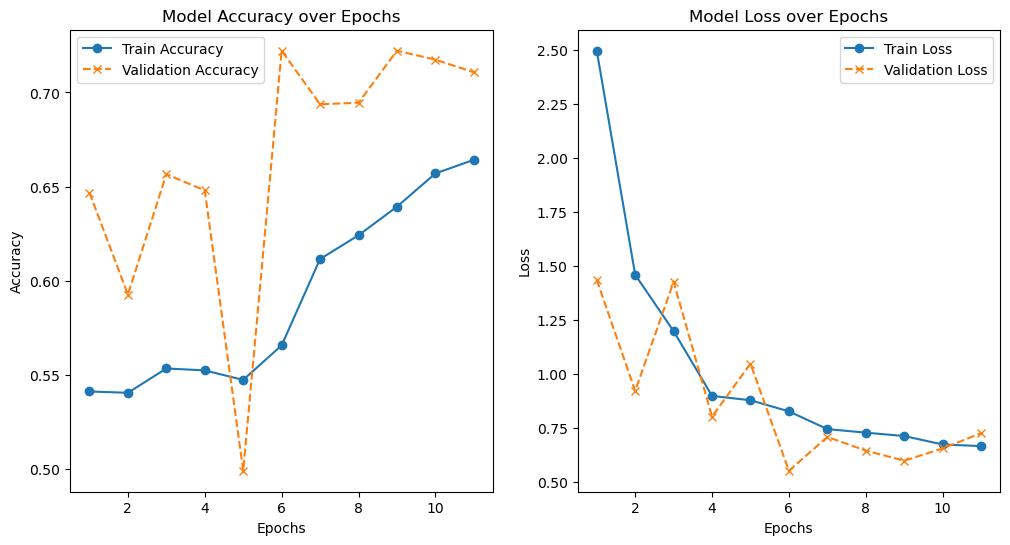

In [ ]:
# Accuray & Loss plot for CNN model 1
visulize_training(history_1)

In [ ]:
# Test the accuracy of CNN model 1
test_cnn_model_1 = cnn_model_1.evaluate(test_ds, verbose=1)
print("Test Loss for CNN model 1: ", test_cnn_model_1[0])
print("Test Accuracy for CNN model 1: ", test_cnn_model_1[1])

81/81 ━━━━━━━━━━━━━━━━━━━━ 41s 468ms/step - accuracy: 0.7201 - loss: 0.5466
Test Loss for CNN model 1:  0.5465579032897949
Test Accuracy for CNN model 1:  0.7201245427131653


### Performance Metrics For CNN 1:

- Test Accuracy: 72.01%
- Test Loss: 0.5465
- Training Accuracy (final epoch): ~66%
- Validation Accuracy (peak): ~72%

### Evaluation:
- Learns basic spatial features from X-ray images.
- Training and validation curves are relatively aligned.
- Limited depth restricts detection of subtle TB and Pneumonia patterns.
- Works well as a baseline benchmark.

## CNN 2

CNN Model 2 is a deeper network that extracts low- to high-level features using convolution layers, reduces feature maps via global average pooling, and classifies images into multiple classes using a softmax output.

1. Sequential() → Builds the model layer by layer
- Why: Simple and clear structure for CNN

2. Conv2D(32, (3,3), activation="relu") → First convolution layer
- Why: Extracts basic features like edges and textures from grayscale images

3. MaxPooling2D(2,2) → Downsamples feature maps
- Why: Reduces spatial size, computation, and helps prevent overfitting

4. BatchNormalization() → Normalizes outputs of previous layer
- Why: Speeds up training and stabilizes learning

5. Conv2D(64, (3,3), activation="relu") → Second convolution layer
- Why: Learns more complex features from previous layer’s outputs

6. Conv2D(128, (3,3), activation="relu") → Third convolution layer
- Why: Captures high-level, abstract features for better classification

7. GlobalAveragePooling2D() → Reduces each feature map to a single number
- Why: Efficient alternative to Flatten, reduces parameters and overfitting

8. Dense(128, activation="relu") → Fully connected layer
- Why: Learns non-linear combinations of extracted features

9. Dropout(0.5) → Randomly drops 50% of neurons
- Why: Prevents overfitting by regularization

10. Dense(num_classes, activation="softmax") → Output layer
- Why: Produces probabilities for each class for multi-class classification

In [ ]:
# Define the CNN model 2
cnn_model_2 = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(256,256,1)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    BatchNormalization(),

    GlobalAveragePooling2D(),
    Dense(128, activation = "relu"),
    Dropout(0.5),

    Dense(num_classes, activation = "softmax"),
])

# Summary of CNN model 2
cnn_model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 127, 127, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,467 (431.51 KB)

 Trainable params: 110,019 (429.76 KB)

 Non-trainable params: 448 (1.75 KB)

- Compiles CNN Model 2 with Adam optimizer, categorical cross-entropy loss, and accuracy metric for multi-class classification same as CNN Model 1.

In [ ]:
# # Compile CNN model 2
# cnn_model_2.compile(
#     optimizer="adam",
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

- This line trains CNN Model 2 on the training dataset while validating on the validation set and uses early stopping to avoid overfitting same as CNN Model 2.

In [ ]:
# # Train the CNN model 2
# history_2 = cnn_model_2.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=[early_stopping])

- This code loads the previously trained CNN Model 2 so it can be used directly for evaluation or predictions.

In [ ]:
# Load the CNN model 2
cnn_model_2 = load_model('cnn_model_2.keras')

- This line saves CNN Model 2 so it can be reused later for testing or predictions without retraining.

In [ ]:
# # Save the CNN model 2
# cnn_model_2.save("cnn_model_2.keras")

- This code loads the saved training history of CNN Model 2 for analysis and visualization.

In [ ]:
with open("history_2.pkl", "rb") as f:
  history_2 = pickle.load(f)

- This code saves the training history of CNN Model 2 so it can be reused for analysis or plotting later.

In [ ]:
# # Save the parameters of CNN 2
# with open("history_2.pkl", "wb") as f:
#     pickle.dump(history_2, f)

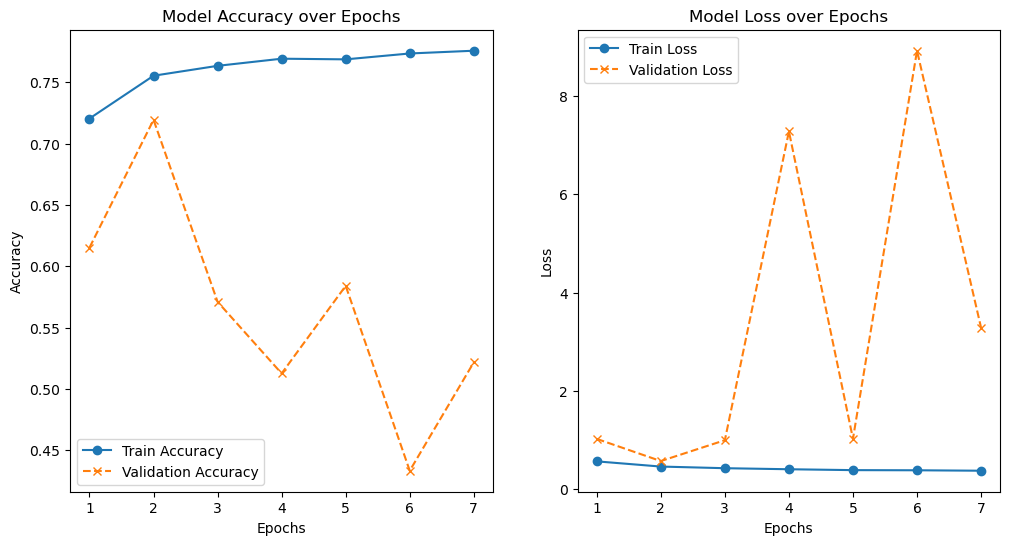

In [ ]:
# Accuray & Loss plot for CNN model 2
visulize_training(history_2)

In [ ]:
# Test the accuracy of CNN model 2
test_cnn_model_2 = cnn_model_2.evaluate(test_ds, verbose=1)
print("Test Loss for CNN model 2: ", test_cnn_model_2[0])
print("Test Accuracy for CNN model 2: ", test_cnn_model_2[1])

81/81 ━━━━━━━━━━━━━━━━━━━━ 55s 639ms/step - accuracy: 0.7135 - loss: 0.5997
Test Loss for CNN model 2:  0.5997363924980164
Test Accuracy for CNN model 2:  0.7135071754455566


### Performance Metrics for CNN 2 Model

- Test Accuracy: 71.35%
- Test Loss: 0.5997
- Training Accuracy (final epoch): ~77%
- Validation Accuracy (lowest): ~43%

### Evaluation

- Increased depth improves training accuracy.
- Large gap between training and validation accuracy.
- Validation loss spikes (up to ~9), indicating instability.
- Suffers from overfitting due to limited dataset size.

## CNN 3

CNN Model 3 is a deeper network that extracts complex image features using multiple convolution layers and performs classification using a dense output layer.

1. Sequential() → Defines a layer-by-layer CNN
- Why: Simple structure for building deep CNNs

2. Conv2D(32, (3,3), activation="relu") → First convolution layer
- Why: Extracts basic visual features like edges

3. Conv2D(64 → 128 → 256) → Increasing number of filters
- Why: Learns progressively complex and high-level features

4. MaxPooling2D(2,2) after each Conv layer
- Why: Reduces spatial dimensions and computation

5. BatchNormalization() after each block
- Why: Stabilizes training and improves convergence

6. Flatten() → Converts feature maps into a 1D vector
- Why: Prepares features for dense layers

7. Dense(256, activation="relu") → Fully connected layer
- Why: Learns strong non-linear feature combinations

8. Dropout(0.5) → Drops 50% neurons randomly
- Why: Prevents overfitting in deep models

9. Dense(num_classes, activation="softmax") → Output layer
- Why: Produces a probability distribution across all classes where the total probability sums to 1 (used in multi-class, single-label classification tasks).

In [ ]:
# Define the CNN model 3
cnn_model_3 = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(256,256,1)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(256, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),
    Dense(256, activation = "relu"),
    Dropout(0.5),

    Dense(num_classes, activation = "softmax"),
])

# Summary of CNN model 3
cnn_model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 127, 127, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,843 (50.49 MB)

 Trainable params: 13,234,883 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

- This code compiles CNN Model 3 using the Adam optimizer, categorical cross-entropy loss, and accuracy metric for multi-class classification.

In [ ]:
# # Compile CNN model 3
# cnn_model_3.compile(
#     optimizer="adam",
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

- This line trains CNN Model 3 using training data while validating performance and applying early stopping to avoid overfitting.

In [ ]:
# # Train the CNN model 3
# history_3 = cnn_model_3.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=[early_stopping])

- This code loads the previously trained CNN Model 3 for direct evaluation or prediction.

In [ ]:
# Load the CNN model 3
cnn_model_3 = load_model('cnn_model_3.keras')

- This line saves CNN Model 3 so it can be reused later without retraining.

In [ ]:
# # Save the CNN model 3
# cnn_model_3.save("cnn_model_3.keras")

- This code loads the saved training history of CNN Model 3 for analysis and visualization.

In [ ]:
with open("history_3.pkl", "rb") as f:
  history_3 = pickle.load(f)

- This code saves the training history of CNN Model 3 so it can be reused later for evaluation or plotting.

In [ ]:
# # Save the parameters of CNN 3
# with open("history_3.pkl", "wb") as f:
#     pickle.dump(history_3, f)

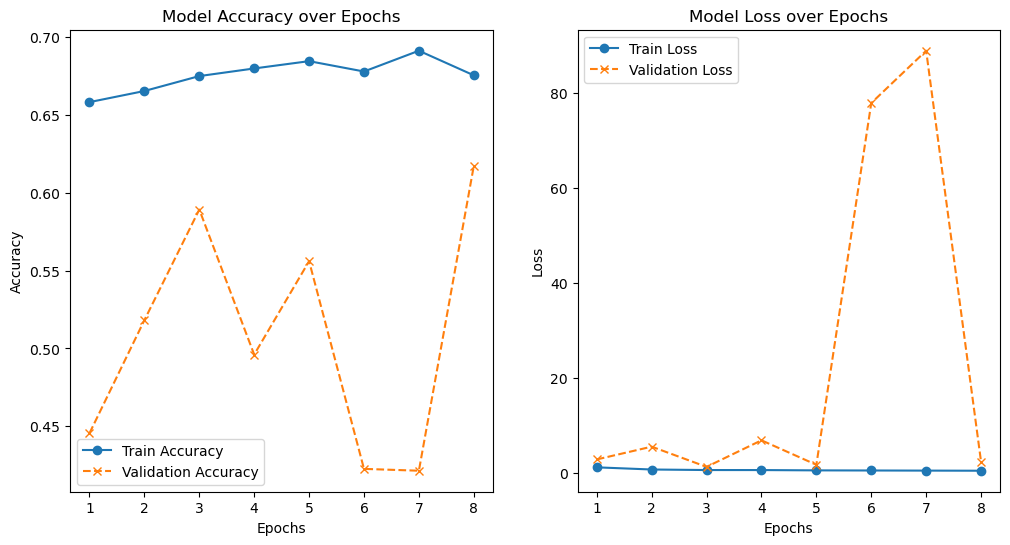

In [ ]:
# Accuray & Loss plot for CNN model 3
visulize_training(history_3)

In [ ]:
# Test the accuracy of CNN model 3
test_cnn_model_3 = cnn_model_3.evaluate(test_ds, verbose=1)
print("Test Loss for CNN model 3: ", test_cnn_model_3[0])
print("Test Accuracy for CNN model 3: ", test_cnn_model_3[1])

81/81 ━━━━━━━━━━━━━━━━━━━━ 66s 778ms/step - accuracy: 0.5909 - loss: 1.2497 
Test Loss for CNN model 3:  1.2496682405471802
Test Accuracy for CNN model 3:  0.590891420841217


### Performance Metrics for CNN 3 Model

- Test Accuracy: 59.09%
- Test Loss: 1.2497
- Training Accuracy (final epoch): ~69%
- Validation Accuracy (lowest): ~42%

### Evaluation

- Deepest CNN with highest number of parameters.
- Severe overfitting and validation collapse.
- Flatten layer increases parameters excessively.
- Model complexity exceeds dataset capability.

## DenseNet121


This code converts grayscale images to RGB so they are compatible with the DenseNet121 pre-trained model.

1. only_rgb(image, label) → Custom mapping function
- Why: Modifies image format without changing labels

2. tf.image.grayscale_to_rgb(image) → Converts grayscale to 3-channel RGB
- Why: DenseNet121 expects 3-channel (RGB) input images

3. Returns (image, label)
- Why: Keeps labels unchanged after image transformation

4. train_ds_dn = train_ds.map(only_rgb)
- Why: Applies RGB conversion to training data

5. val_ds_dn = val_ds.map(only_rgb)
- Why: Ensures validation data matches training format

6. test_ds_dn = test_ds.map(only_rgb)
- Why: Ensures test data matches model input requirements

In [ ]:
def only_rgb(image, label):
    image = tf.image.grayscale_to_rgb(image)
    return image, label

train_ds_dn = train_ds.map(only_rgb)
val_ds_dn   = val_ds.map(only_rgb)
test_ds_dn  = test_ds.map(only_rgb)

This code loads a pre-trained DenseNet121 model without the top layer to use it as a feature extractor for image classification.

1. DenseNet121 → Pre-trained convolutional neural network
- Why: Provides strong feature extraction using dense connections

2. include_top=False → Excludes the original classification layers
- Why: Allows custom classification head for the current problem

3. weights='imagenet' → Loads ImageNet-trained weights
- Why: Uses transfer learning for better performance and faster convergence

4. input_shape=(256,256,3) → Defines RGB image input size
- Why: Matches converted RGB dataset and model requirement

5. pooling='avg' → Applies global average pooling
- Why: Reduces feature maps into a single feature vector efficiently

In [ ]:
from keras.applications.densenet import DenseNet121

densenet = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(256, 256, 3),
    pooling='avg',
)

densenet.summary()

Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 64, 64,    │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 6,953,856 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

This code adds a custom fully connected head to DenseNet121 for multi-class classification and creates a complete trainable model.

1. x = densenet.output
- Why: Gets feature vector from DenseNet121 to build custom classification layers

2. Dense(1024, activation='relu') → Fully connected layer
- Why: Learns complex combinations of extracted features

3. Dense(512, activation='relu') → Second dense layer
- Why: Further refines features for better classification

4. BatchNormalization() → Normalizes activations
- Why: Speeds up training and stabilizes learning

5. Dropout(0.5) → Randomly drops 50% neurons
- Why: Prevents overfitting in the custom head

6. Dense(num_classes, activation='softmax') → Output layer
- Why: Produces class probabilities for multi-class classification

7. densenet_model = Model(inputs=densenet.input, outputs=output)
- Why: Combines DenseNet base and custom head into one trainable model

In [ ]:
x = densenet.output

x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

output = Dense(num_classes, activation='softmax')(x)

densenet_model = Model(inputs=densenet.input, outputs=output)
densenet_model.summary()

Model: "functional_81"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 64, 64,    │     12,288 │ conv2_block2_0_r

 Total params: 8,615,491 (32.87 MB)

 Trainable params: 8,530,819 (32.54 MB)

 Non-trainable params: 84,672 (330.75 KB)

This code freezes all DenseNet layers so only the custom head is trained, leveraging pre-trained features efficiently.
Uses DenseNet as a fixed feature extractor and trains only the custom classification head, It reduces training time and avoids overfitting when dataset is small

In [ ]:
# for layer in densenet.layers:
#     layer.trainable = False

- This code compiles the DenseNet121-based model with Adam optimizer, categorical cross-entropy loss, and accuracy metric for multi-class classification.

In [ ]:
# # Compile Densenet Model
# densenet_model.compile(
#     optimizer="adam",
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

- This line trains the DenseNet121-based model on the RGB dataset while validating performance and using early stopping to avoid overfitting.

In [ ]:
# # Train the Densenet Model
# history_4 = densenet_model.fit(train_ds_dn, epochs=50, validation_data=val_ds_dn, callbacks=[early_stopping])

- This code loads a previously trained DenseNet121-based model for direct evaluation or predictions.

In [ ]:
# Load the DenseNet
densenet_model = load_model('densenet.keras')

- This line saves the trained DenseNet121-based model so it can be reused later without retraining.

In [ ]:
# # Save the DenseNet Model
# densenet_model.save("densenet.keras")

- This code loads the saved training history of the DenseNet121-based model for analysis and visualization.

In [ ]:
with open("history_4.pkl", "rb") as f:
  history_4 = pickle.load(f)

- This code saves the training history of the DenseNet121-based model so it can be reused later for evaluation or plotting.

In [ ]:
# # Save the parameters of DenseNet Model
# with open("history_4.pkl", "wb") as f:
#     pickle.dump(history_4, f)

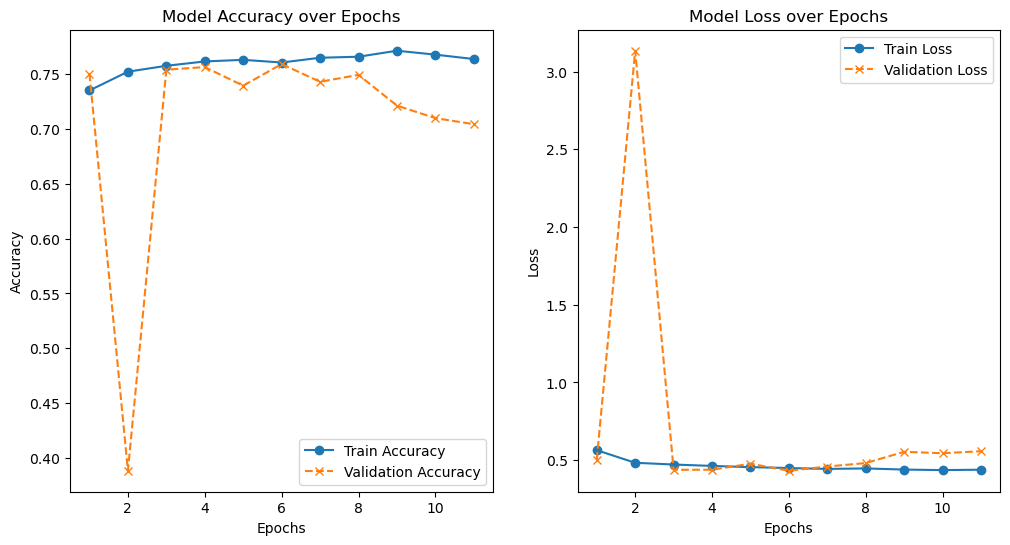

In [ ]:
# Accuray & Loss plot for DenseNet
visulize_training(history_4)

In [ ]:
# Test the accuracy of DenseNet
test_densenet_model = densenet_model.evaluate(test_ds_dn, verbose=1)
print("Test Loss for DenseNet: ", test_densenet_model[0])
print("Test Accuracy for DenseNet: ", test_densenet_model[1])

81/81 ━━━━━━━━━━━━━━━━━━━━ 296s 3s/step - accuracy: 0.7672 - loss: 0.4236
Test Loss for DenseNet:  0.423624187707901
Test Accuracy for DenseNet:  0.7672246098518372


### Performance Metrics for DenseNet121

- Test Accuracy: 76.72%
- Test Loss: 0.4236
- Training Accuracy (final epoch): ~77%
- Validation Accuracy: ~70–75%

### Evaluation

- Best performing model across all metrics.
- Dense connections enable effective feature reuse.
- Pretrained ImageNet weights capture medical textures.
- Minimal overfitting and stable convergence.

### Comparative Summary Table

| Model        | Test Accuracy | Test Loss | Overfitting |
|-------------|---------------|-----------|-------------|
| CNN 1       | 72.01%        | 0.5465    | Low         |
| CNN 2       | 71.35%        | 0.5997    | High        |
| CNN 3       | 59.09%        | 1.2497    | Very High   |
| DenseNet121 | 76.72%        | 0.4236    | Minimal     |



### Final Conclusion:
DenseNet121 achieved the highest test accuracy (76.72%) and lowest loss (0.4236), demonstrating superior generalization compared to custom CNN architectures, making it the most suitable model for automated chest disease classification.